# Notebook 4. Финальный fine-tuning SASRec

В Notebook 3 были проверены первые SASRec-кандидаты: sasrec_base, sasrec_stronger и sasrec_sampled_100neg.

По основной ranking-метрике Recall@50 лучшим оказался sasrec_stronger:

- sasrec_stronger: Recall@50 ≈ 0.110
- sasrec_base: Recall@50 ≈ 0.107
- sasrec_sampled_100neg: Recall@50 ≈ 0.055.

При этом sasrec_base был немного лучше по NDCG@50, MRR@50 и Catalog Coverage@50. Поэтому в этом ноутбуке я не фиксирую одну модель сразу, а провожу локальный fine-tuning вокруг двух наиболее содержательных направлений: более сильной attention-архитектуры и более устойчивого базового full-softmax SASRec.

Поэтому здесь я не запускаю большой перебор параметров, а проверяю несколько понятных направлений улучшения: больше обучающих состояний на пользователя, более длинный контекст, более сильная attention-архитектура и более широкий hidden representation. Финальная модель выбирается по validation Recall@50. Test используется только после выбора конфигурации, чтобы не подбирать модель по тестовой выборке.

## 1. Импорты и загрузка данных

В этом разделе загружается финальный сабсэмпл, фиксируется random seed и выбирается устройство для обучения. Состав данных здесь уже не меняется: дальше сравниваются только разные конфигурации SASRec.

In [ ]:
!pip install -q tqdm pyarrow

In [ ]:

import os
import json
import time
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

pd.options.display.max_columns = 160
pd.options.display.max_rows = 160
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("device:", device)


device: cuda


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

DATA_DIR = "/content/drive/MyDrive/Курсовая/final_subsample"
# загружаю финальный сабсэмпл
final_events = pd.read_parquet(f"{DATA_DIR}/final_events.parquet")

# привожу timestamp к числовому типу
final_events["timestamp"] = pd.to_numeric(final_events["timestamp"], errors="coerce")
final_events = final_events.dropna(subset=["timestamp"])
final_events["timestamp"] = final_events["timestamp"].astype("int64")

final_events["is_organic"] = final_events["is_organic"].astype(int)
final_events["played_ratio_pct"] = pd.to_numeric(final_events["played_ratio_pct"], errors="coerce")

final_events = (final_events.drop_duplicates(subset=["uid", "item_id", "timestamp"]).sort_values(["uid", "timestamp"]).reset_index(drop=True))

print("events:", final_events.shape)
print("users:", final_events["uid"].nunique())
print("items:", final_events["item_id"].nunique())

final_events.head()

Mounted at /content/drive
events: (10206636, 5)
users: 4998
items: 300000


,uid,item_id,timestamp,is_organic,played_ratio_pct
0,100,1441281,39420,0,100.0
1,100,3397170,40360,0,46.0
2,100,1449307,40640,0,100.0
3,100,2996197,40885,0,100.0
4,100,6474571,41130,0,100.0


## 2. Leave-one-out split

Тут делаем все тоже самое, что и ранее. Для финального fine-tuning используется та же схема оценки, что и в предыдущих ноутбуках: последнее событие пользователя берётся как test target, предпоследнее - как validation target, а вся более ранняя история используется для обучения.

Дополнительно оставляются только warm-start случаи: пользователь и target item должны присутствовать в обучающей части. Это нужно, чтобы качество модели оценивалось на задаче ранжирования известных item, а не на проблеме cold-start.

In [ ]:
# строю leave-one-out split для next-item prediction
def build_leave_one_out_split(events: pd.DataFrame, min_events: int = 3):
    df = events.sort_values(["uid", "timestamp"]).copy()

    # оставляю пользователей, у которых хватает истории для train, validation и test
    lengths = df.groupby("uid")["item_id"].transform("size")
    df = df[lengths >= min_events].copy()

    df["pos"] = df.groupby("uid").cumcount()
    df["n_events"] = df.groupby("uid")["item_id"].transform("size")

    train = df[df["pos"] < df["n_events"] - 2].copy()
    val = df[df["pos"] == df["n_events"] - 2].copy()
    test = df[df["pos"] == df["n_events"] - 1].copy()

    return train, val, test

In [ ]:
train_events, val_events, test_events = build_leave_one_out_split(final_events, min_events=3)

train_users = set(train_events["uid"].unique())
train_items = set(train_events["item_id"].unique())

In [ ]:
# оставляю validation только для warm-start пользователей и треков
val_events = val_events[val_events["uid"].isin(train_users) & val_events["item_id"].isin(train_items)].copy()
valid_val_users = set(val_events["uid"].unique())
# оставляю test только для пользователей и треков, известных после train/validation
test_events = test_events[test_events["uid"].isin(valid_val_users) & test_events["item_id"].isin(train_items)].copy()

test_users = set(test_events["uid"].unique())
# оставляю validation только для warm-start пользователей и треков
val_events = val_events[val_events["uid"].isin(test_users)].copy()
train_events_eval = train_events[train_events["uid"].isin(test_users)].copy()

In [ ]:
split_summary = pd.DataFrame({
    "part": ["train_events", "validation_targets", "test_targets"],
    "rows": [len(train_events_eval), len(val_events), len(test_events)],
    "users": [
        train_events_eval["uid"].nunique(),
        val_events["uid"].nunique(),
        test_events["uid"].nunique()
    ],
    "items": [
        train_events_eval["item_id"].nunique(),
        val_events["item_id"].nunique(),
        test_events["item_id"].nunique()
    ]
})

split_summary

,part,rows,users,items
0,train_events,10196170,4973,299841
1,validation_targets,4973,4973,3806
2,test_targets,4973,4973,3846


**Вывод:** После фильтрации в выборке остаются пользователи, для которых можно построить train history, validation target и test target. Все следующие SASRec-конфигурации сравниваются в одной и той же leave-one-out постановке.

## 3. Sequence dataset utilities

На этом этапе исходные события переводятся в формат, удобный для обучения SASRec. Для каждого пользователя строится последовательность прослушанных треков, затем она обрезается до заданной длины max_len и дополняется padding слева.

Для validation используется история из train и validation target, а для test - история train плюс validation item. Так сохраняется хронологическая логика leave-one-out оценки.

In [ ]:
# дополняю последовательность слева до фиксированной длины
def pad_sequence(seq, max_len, pad_value=0):
    seq = seq[-max_len:]
    return [pad_value] * (max_len - len(seq)) + seq

In [ ]:
# собираю train, validation и test примеры для sasrec
def build_sequence_samples(train_events_eval: pd.DataFrame, val_events: pd.DataFrame, test_events: pd.DataFrame, item2idx: dict, max_len: int = 100, max_train_samples_per_user: int = 50):

    train_encoded = train_events_eval.sort_values(["uid", "timestamp"]).copy()
    train_encoded["item_idx"] = train_encoded["item_id"].map(item2idx)

    val_encoded = val_events[val_events["item_id"].isin(item2idx)].copy()
    val_encoded["target_idx"] = val_encoded["item_id"].map(item2idx).astype(int)

    test_encoded = test_events[test_events["item_id"].isin(item2idx)].copy()
    test_encoded["target_idx"] = test_encoded["item_id"].map(item2idx).astype(int)

    user_train_seq = train_encoded.groupby("uid")["item_idx"].apply(list).to_dict()
    user_val_target = dict(zip(val_encoded["uid"], val_encoded["target_idx"]))
    user_test_target = dict(zip(test_encoded["uid"], test_encoded["target_idx"]))

    # здесь будут обучающие состояния из пользовательских историй
    train_samples = []
    val_samples = []
    test_samples = []

    for uid, seq in user_train_seq.items():
        if len(seq) >= 2:
            # беру последние обучающие состояния, чтобы не раздувать train слишком сильно
            start_i = max(1, len(seq) - max_train_samples_per_user)

            for i in range(start_i, len(seq)):
                train_samples.append({
                    "uid": uid,
                    "input_seq": pad_sequence(seq[:i], max_len),
                    "target": seq[i]
                })

        if uid in user_val_target and len(seq) >= 1:
            # для test добавляю validation item в доступную историю пользователя
            val_samples.append({
                "uid": uid,
                "input_seq": pad_sequence(seq, max_len),
                "target": user_val_target[uid]
            })

        if uid in user_test_target and uid in user_val_target and len(seq) >= 1:
            test_input = seq + [user_val_target[uid]]
            test_samples.append({
                "uid": uid,
                "input_seq": pad_sequence(test_input, max_len),
                "target": user_test_target[uid]
            })

    return (
        pd.DataFrame(train_samples),
        pd.DataFrame(val_samples),
        pd.DataFrame(test_samples)
    )

In [ ]:
# dataset для sasrec: история пользователя и следующий item
class SeqRecDataset(Dataset):

    def __init__(self, df: pd.DataFrame):
        self.inputs = df["input_seq"].tolist()
        self.targets = df["target"].tolist()

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.inputs[idx], dtype=torch.long),
            torch.tensor(self.targets[idx], dtype=torch.long)
        )


# пересобираю dataloaders под конкретные параметры эксперимента
def rebuild_sequence_dataloaders(
    train_events_eval,
    val_events,
    test_events,
    max_len=100,
    max_train_samples_per_user=50,
    batch_size=128,
    num_workers=0
):
    item_ids = train_events_eval["item_id"].drop_duplicates().tolist()
    item2idx = {item_id: idx + 1 for idx, item_id in enumerate(item_ids)}
    idx2item = {idx: item_id for item_id, idx in item2idx.items()}
    num_items = len(item2idx) + 1

    train_df, val_df, test_df = build_sequence_samples(
        train_events_eval=train_events_eval,
        val_events=val_events,
        test_events=test_events,
        item2idx=item2idx,
        max_len=max_len,
        max_train_samples_per_user=max_train_samples_per_user
    )

    train_loader = DataLoader(
        SeqRecDataset(train_df),
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        SeqRecDataset(val_df),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )

    test_loader = DataLoader(
        SeqRecDataset(test_df),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )

    info = {
        "max_len": max_len,
        "max_train_samples_per_user": max_train_samples_per_user,
        "batch_size": batch_size,
        "num_items": num_items,
        "train_samples": len(train_df),
        "val_samples": len(val_df),
        "test_samples": len(test_df),
        "train_batches": len(train_loader),
        "val_batches": len(val_loader),
        "test_batches": len(test_loader),
    }

    return train_loader, val_loader, test_loader, item2idx, idx2item, num_items, info


**Вывод:** Данные подготовлены в формате последовательность - следующий трек. Теперь разные SASRec-конфигурации могут использовать один и тот же формат входа, а отличаться будут только параметры подготовки истории и архитектуры.

**Вывод:** После подготовки данных каждая модель получает одинаковый формат входа: последовательность предыдущих треков и один следующий target item. Это позволяет честно сравнивать SASRec-конфигурации между собой, меняя только параметры модели и обучения.

## 4. Метрики и функции обучения

В этом разделе задаются функции для обучения и оценки SASRec. Модель оценивается в задаче next-item ranking: для каждого пользователя нужно проверить, попал ли реальный следующий трек в top-K рекомендаций и насколько высоко он оказался в списке.

Основной горизонт для итогового сравнения - @50, но метрики @10 также сохраняются как дополнительная проверка.

In [ ]:
# считаю сумму hits, ndcg и mrr внутри batch
def ranking_sums_at_k(logits, targets, k):
    topk = torch.topk(logits, k=k, dim=1).indices

    hits = 0.0
    ndcg_sum = 0.0
    mrr_sum = 0.0

    for i in range(targets.size(0)):
        preds = topk[i].tolist()
        target = targets[i].item()

        if target in preds:
            rank = preds.index(target) + 1
            hits += 1.0
            ndcg_sum += 1.0 / np.log2(rank + 1)
            mrr_sum += 1.0 / rank

    return hits, ndcg_sum, mrr_sum

In [ ]:
@torch.no_grad()
# единая оценка модели через full ranking
def evaluate_full_softmax(model, loader, ks=(10, 50)):
    model.eval()

    total = 0
    hits = {k: 0.0 for k in ks}
    ndcgs = {k: 0.0 for k in ks}
    mrrs = {k: 0.0 for k in ks}

    for x, y in tqdm(loader, leave=False):
        x = x.to(device)
        y = y.to(device)

        logits = model(x)

        if logits.size(1) > 0:
            logits[:, 0] = -1e9

        total += y.size(0)

        for k in ks:
            batch_hits, batch_ndcg, batch_mrr = ranking_sums_at_k(logits, y, k)
            hits[k] += batch_hits
            ndcgs[k] += batch_ndcg
            mrrs[k] += batch_mrr

    out = {}
    for k in ks:
        recall = hits[k] / max(1, total)
        out[f"Recall@{k}"] = recall
        out[f"Precision@{k}"] = recall / k
        out[f"NDCG@{k}"] = ndcgs[k] / max(1, total)
        out[f"MRR@{k}"] = mrrs[k] / max(1, total)

    return out

In [ ]:
def train_one_epoch_full_softmax(model, loader, optimizer, criterion, max_batches=None, grad_clip=1.0):
    model.train()

    loss_sum = 0.0
    used_batches = 0
    start = time.time()

    for batch_idx, (x, y) in enumerate(tqdm(loader, leave=False)):
        if max_batches is not None and batch_idx >= max_batches:
            break

        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()

        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

        optimizer.step()

        loss_sum += loss.item()
        used_batches += 1

    return loss_sum / max(1, used_batches), time.time() - start, used_batches

### Метрики покрытия, разнообразия и popularity bias

Эти метрики считаются не по попаданию в target, а по самим рекомендательным спискам. Они нужны, чтобы сравнивать модели не только по точности, но и по тому, насколько широко они покрывают каталог и насколько сильно концентрируются на популярных треках.

In [ ]:
# строю справочник популярности треков по train-части
def build_popularity_reference(train_events_eval: pd.DataFrame):
    item_pop_df = (train_events_eval.groupby("item_id").size().rename("train_popularity").reset_index())
    item_pop_df["log_popularity"] = np.log1p(item_pop_df["train_popularity"])
    item_pop_df["popularity_bin"] = pd.qcut(item_pop_df["log_popularity"].rank(method="first"), q=10, labels=False, duplicates="drop").astype(int)

    popularity_bin_map = dict(zip(item_pop_df["item_id"], item_pop_df["popularity_bin"]))
    item_universe = train_events_eval["item_id"].unique()

    return item_pop_df, popularity_bin_map, item_universe

In [ ]:
# gini показывает концентрацию рекомендаций на малом числе треков
def gini_from_counts(counts):
    values = np.array(list(counts), dtype=float)

    if len(values) == 0:
        return np.nan

    if np.all(values == 0):
        return 0.0

    values = np.sort(values)
    n = len(values)
    cum_values = np.cumsum(values)

    return (n + 1 - 2 * np.sum(cum_values) / cum_values[-1]) / n

In [ ]:
def flatten_recommendations(recs: dict, k: int):
    flat = []

    for items in recs.values():
        flat.extend(items[:k])

    return flat

In [ ]:
# считаю метрики покрытия каталога и концентрации рекомендаций
def recommendation_exposure_metrics(recs: dict, model_name: str, item_universe, popularity_bin_map: dict, ks=(10, 50)):
    rows = []
    catalog_size = len(set(item_universe))

    for k in ks:
        flat_recs = flatten_recommendations(recs, k=k)

        if len(flat_recs) == 0:
            rows.append({
                "model": model_name,
                "K": k,
                "Unique Recommended Items@K": 0,
                "Catalog Coverage@K": 0.0,
                "Gini@K": np.nan,
                "Top Popularity Bin Share@K": np.nan,
            })
            continue

        rec_counts = pd.Series(flat_recs).value_counts()
        unique_recs = int(rec_counts.shape[0])

        rec_bins = pd.Series([popularity_bin_map.get(item, np.nan) for item in flat_recs]).dropna()

        top_bin_share = float((rec_bins >= 8).mean()) if len(rec_bins) > 0 else np.nan

        rows.append({
            "model": model_name,
            "K": k,
            "Unique Recommended Items@K": unique_recs,
            "Catalog Coverage@K": unique_recs / max(1, catalog_size),
            "Gini@K": gini_from_counts(rec_counts.values)

        })

    return pd.DataFrame(rows)

In [ ]:
# генерирую top-k рекомендации для coverage и popularity-bias метрик
@torch.no_grad()
def generate_sasrec_recommendations(model, loader, eval_df: pd.DataFrame, idx2item: dict, top_k=50):
    model.eval()

    recs = {}
    eval_users = eval_df["uid"].tolist()
    pointer = 0

    for x, y in tqdm(loader, leave=False):
        x = x.to(device)
        logits = model(x)

        if logits.size(1) > 0:
            logits[:, 0] = -1e9

        topk = torch.topk(logits, k=top_k, dim=1).indices.cpu().numpy()

        for pred_idxs in topk:
            uid = eval_users[pointer]
            recs[uid] = [
                idx2item[int(idx)]
                for idx in pred_idxs
                if int(idx) in idx2item
            ]
            pointer += 1

    return recs


item_pop_df, popularity_bin_map, item_universe = build_popularity_reference(train_events_eval)
item_pop_df.head()

,item_id,train_popularity,log_popularity,popularity_bin
0,81,1,0.693147,0
1,127,2,1.098612,3
2,142,1,0.693147,0
3,167,2,1.098612,3
4,206,412,6.023448,9


## 5. Архитектура SASRec

В этом разделе задаётся основная архитектура SASRec. Модель получает последовательность предыдущих треков пользователя, добавляет позиционную информацию и пропускает последовательность через causal Transformer Encoder.

Causal mask нужен для того, чтобы модель использовала только прошлые события и не смотрела в будущие позиции. Для прогноза следующего трека берётся скрытое состояние последнего непустого элемента истории.

In [ ]:
# sasrec для предсказания следующего трека
class SASRec(nn.Module):
    def __init__(
        self,
        num_items: int,
        max_len: int,
        hidden_dim: int = 128,
        num_heads: int = 2,
        num_layers: int = 1,
        dropout: float = 0.2,
        padding_idx: int = 0
    ):
        super().__init__()

        self.num_items = num_items
        self.max_len = max_len
        self.hidden_dim = hidden_dim
        self.padding_idx = padding_idx
        # item embeddings переводят треки во внутренние dense-векторы
        self.item_embedding = nn.Embedding(
            num_items,
            hidden_dim,
            padding_idx=padding_idx
        )

        # position embeddings добавляют информацию о порядке треков
        self.position_embedding = nn.Embedding(max_len, hidden_dim)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 4,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_dim)

    def encode(self, x):
        batch_size, seq_len = x.size()

        positions = (
            torch.arange(seq_len, device=x.device)
            .unsqueeze(0)
            .expand(batch_size, seq_len)
        )

        h = self.item_embedding(x) + self.position_embedding(positions)
        h = self.dropout(h)

        padding_mask = x.eq(self.padding_idx)

        causal_mask = torch.triu(
            torch.ones(seq_len, seq_len, device=x.device, dtype=torch.bool),
            diagonal=1
        )

        h = self.encoder(
            h,
            mask=causal_mask,
            src_key_padding_mask=padding_mask
        )

        h = self.layer_norm(h)

        lengths = (~padding_mask).sum(dim=1).clamp(min=1)
        last_idx = (lengths - 1).view(-1, 1, 1).expand(-1, 1, self.hidden_dim)
        # беру последнее непустое состояние как представление пользовательского контекста
        last_hidden = h.gather(dim=1, index=last_idx).squeeze(1)

        return last_hidden

    def forward(self, x):
        user_repr = self.encode(x)

         # считаю scores по всем item через dot product
        logits = user_repr @ self.item_embedding.weight.T
        logits[:, self.padding_idx] = -1e9

        return logits


**Вывод:** Архитектура SASRec подходит для задачи next-track prediction, так как она учитывает порядок прослушиваний и может моделировать зависимости между разными позициями в пользовательской истории. В дальнейшем в fine-tuning будут меняться только ключевые параметры этой архитектуры: длина истории, число attention heads, число layers и размер hidden representation.

## 6. Прогон экспериментов

В этом блоке задаётся единая функция запуска SASRec-эксперимента. Она создаёт модель по заданной конфигурации, обучает её несколько эпох и после каждой эпохи считает validation-метрики. Лучшая версия модели выбирается по validation Recall@50. Это позволяет сравнивать разные конфигурации по одному правилу и не выбирать модель по test-результату.

In [ ]:
# запуск одной sasrec-конфигурации с контролем по validation
def run_sasrec_val_only(
    config: dict,
    train_loader,
    val_loader,
    num_items: int,
    max_len: int,
    device,
    max_batches_per_epoch=None,
    patience=6
):
    model = SASRec(
        num_items=num_items,
        max_len=max_len,
        hidden_dim=config["hidden_dim"],
        num_heads=config["num_heads"],
        num_layers=config["num_layers"],
        dropout=config["dropout"],
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config.get("weight_decay", 0.0)
    )

    criterion = nn.CrossEntropyLoss()

    # лучшая эпоха выбирается по validation Recall@50
    best_state = None
    best_val_recall50 = -1
    best_epoch = 0
    no_improve = 0

    history = []

    for epoch in range(config["epochs"]):
        train_loss, epoch_time, used_batches = train_one_epoch_full_softmax(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            max_batches=max_batches_per_epoch,
            grad_clip=config.get("grad_clip", 1.0)
        )

        val_metrics = evaluate_full_softmax(model, val_loader, ks=(10, 50))

        row = {
            "experiment": config["name"],
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "epoch_time_sec": epoch_time,
            "used_batches": used_batches,
            **{f"val_{k}": v for k, v in val_metrics.items()}
        }

        history.append(row)

        current_val = val_metrics["Recall@50"]

        if current_val > best_val_recall50:
            best_val_recall50 = current_val
            best_epoch = epoch + 1
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            no_improve = 0
        else:
            no_improve += 1

        print(f"\n{config['name']} | epoch {epoch + 1}/{config['epochs']}")
        print(f"train loss: {train_loss:.4f}")
        print(f"time sec: {epoch_time:.2f}")
        print("val:", val_metrics)

        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    result = {
        "experiment": config["name"],
        "model": "SASRec",
        "training_type": "full_softmax",
        "hidden_dim": config["hidden_dim"],
        "num_heads": config["num_heads"],
        "num_layers": config["num_layers"],
        "dropout": config["dropout"],
        "lr": config["lr"],
        "weight_decay": config.get("weight_decay", 0.0),
        "planned_epochs": config["epochs"],
        "best_epoch": best_epoch,
        "best_val_Recall@50": best_val_recall50,
    }

    return model, pd.DataFrame(history), result


## 7. План final fine-tuning

План fine-tuning строится на результатах Notebook 3. В предыдущем ноутбуке sasrec_stronger показал лучший Recall@50, но sasrec_base был конкурентен по NDCG@50, MRR@50 и Catalog Coverage@50. Поэтому здесь проверяются не только более сложные архитектуры, но и практичные варианты улучшения базового full-softmax SASRec.

В fine-tuning включены несколько направлений:

- longer training для базовой архитектуры
- больше train samples per user
- более длинный пользовательский контекст
- продолжение sasrec_stronge - логики
- более широкий hidden representation.

Все конфигурации обучаются на одинаковом числе эпох и сравниваются по validation Recall@50. После этого выбранная конфигурация дообучается дольше и один раз оценивается на test.

In [ ]:
# набор конфигураций для локального fine-tuning
sasrec_finetune_plan = [
    {
        "name": "sasrec_base_longer",
        "max_len": 100,
        "max_train_samples_per_user": 50,
        "batch_size": 128,
        "hidden_dim": 128,
        "num_heads": 2,
        "num_layers": 1,
        "dropout": 0.2,
        "lr": 5e-4,
        "weight_decay": 1e-5,
        "grad_clip": 1.0,
        "epochs": 12,
    },
    {
        "name": "sasrec_more_samples_75",
        "max_len": 100,
        "max_train_samples_per_user": 75,
        "batch_size": 128,
        "hidden_dim": 128,
        "num_heads": 2,
        "num_layers": 1,
        "dropout": 0.2,
        "lr": 5e-4,
        "weight_decay": 1e-5,
        "grad_clip": 1.0,
        "epochs": 12,
    },
    {
        "name": "sasrec_len150_samples50",
        "max_len": 150,
        "max_train_samples_per_user": 50,
        "batch_size": 128,
        "hidden_dim": 128,
        "num_heads": 2,
        "num_layers": 1,
        "dropout": 0.2,
        "lr": 5e-4,
        "weight_decay": 1e-5,
        "grad_clip": 1.0,
        "epochs": 12,
    },
    {
        "name": "sasrec_stronger_long",
        "max_len": 100,
        "max_train_samples_per_user": 50,
        "batch_size": 128,
        "hidden_dim": 128,
        "num_heads": 4,
        "num_layers": 2,
        "dropout": 0.2,
        "lr": 5e-4,
        "weight_decay": 1e-5,
        "grad_clip": 1.0,
        "epochs": 12,
    },
    {
        "name": "sasrec_h256_simple",
        "max_len": 100,
        "max_train_samples_per_user": 50,
        "batch_size": 128,
        "hidden_dim": 256,
        "num_heads": 4,
        "num_layers": 1,
        "dropout": 0.3,
        "lr": 3e-4,
        "weight_decay": 1e-5,
        "grad_clip": 1.0,
        "epochs": 12,
    },
]

RUN_ONLY_FAST_CORE = False

if RUN_ONLY_FAST_CORE:
    sasrec_finetune_plan = sasrec_finetune_plan[:2]

sasrec_finetune_plan

[{'name': 'sasrec_base_longer',
  'max_len': 100,
  'max_train_samples_per_user': 50,
  'batch_size': 128,
  'hidden_dim': 128,
  'num_heads': 2,
  'num_layers': 1,
  'dropout': 0.2,
  'lr': 0.0005,
  'weight_decay': 1e-05,
  'grad_clip': 1.0,
  'epochs': 12},
 {'name': 'sasrec_more_samples_75',
  'max_len': 100,
  'max_train_samples_per_user': 75,
  'batch_size': 128,
  'hidden_dim': 128,
  'num_heads': 2,
  'num_layers': 1,
  'dropout': 0.2,
  'lr': 0.0005,
  'weight_decay': 1e-05,
  'grad_clip': 1.0,
  'epochs': 12},
 {'name': 'sasrec_len150_samples50',
  'max_len': 150,
  'max_train_samples_per_user': 50,
  'batch_size': 128,
  'hidden_dim': 128,
  'num_heads': 2,
  'num_layers': 1,
  'dropout': 0.2,
  'lr': 0.0005,
  'weight_decay': 1e-05,
  'grad_clip': 1.0,
  'epochs': 12},
 {'name': 'sasrec_stronger_long',
  'max_len': 100,
  'max_train_samples_per_user': 50,
  'batch_size': 128,
  'hidden_dim': 128,
  'num_heads': 4,
  'num_layers': 2,
  'dropout': 0.2,
  'lr': 0.0005,
  'weig

**Вывод:** Fine-tuning plan покрывает основные гипотезы улучшения SASRec, но не превращается в полный grid search. Такой подход позволяет сохранить эксперимент управляемым: каждая конфигурация отличается от базовой модели по одному-двум содержательным параметрам, поэтому результаты легче интерпретировать.

## 8. Запуск fine-tuning экспериментов

В этом блоке запускаются все конфигурации из fine-tuning plan. Для каждой конфигурации отдельно пересобираются dataloaders, потому что могут отличаться длина истории и число обучающих примеров на пользователя. Тест здесь не используется. На этом этапе модели сравниваются только по validation, чтобы честно выбрать конфигурацию для финального обучения.

In [ ]:
sasrec_finetune_results = []
sasrec_finetune_histories = {}
sasrec_finetune_models = {}
sasrec_finetune_dataset_info = {}

In [ ]:
# последовательно запускаю все fine-tuning конфигурации
for exp_config in sasrec_finetune_plan:
    print("=" * 90)
    print("Running fine-tuning experiment:", exp_config["name"])
    print("=" * 90)

    (
        exp_train_loader,
        exp_val_loader,
        exp_test_loader,
        exp_item2idx,
        exp_idx2item,
        exp_num_items,
        exp_dataset_info
    ) = rebuild_sequence_dataloaders(
        train_events_eval=train_events_eval,
        val_events=val_events,
        test_events=test_events,
        max_len=exp_config["max_len"],
        max_train_samples_per_user=exp_config["max_train_samples_per_user"],
        batch_size=exp_config["batch_size"]
    )

    print("Dataset info:")
    print(exp_dataset_info)

    # отделяю параметры модели от параметров подготовки данных
    model_config = {
        "name": exp_config["name"],
        "hidden_dim": exp_config["hidden_dim"],
        "num_heads": exp_config["num_heads"],
        "num_layers": exp_config["num_layers"],
        "dropout": exp_config["dropout"],
        "lr": exp_config["lr"],
        "weight_decay": exp_config["weight_decay"],
        "grad_clip": exp_config["grad_clip"],
        "epochs": exp_config["epochs"],
    }

    # обучаю модель и сохраняю лучший validation результат
    model, history, result = run_sasrec_val_only(
        config=model_config,
        train_loader=exp_train_loader,
        val_loader=exp_val_loader,
        num_items=exp_num_items,
        max_len=exp_config["max_len"],
        device=device,
        max_batches_per_epoch=None,
        patience=6
    )

    result.update({
        "max_len": exp_config["max_len"],
        "max_train_samples_per_user": exp_config["max_train_samples_per_user"],
        "batch_size": exp_config["batch_size"],
        "train_samples": exp_dataset_info["train_samples"],
        "val_samples": exp_dataset_info["val_samples"],
        "test_samples": exp_dataset_info["test_samples"],
        "train_batches": exp_dataset_info["train_batches"],
    })

    sasrec_finetune_results.append(result)
    sasrec_finetune_histories[exp_config["name"]] = history
    sasrec_finetune_models[exp_config["name"]] = model
    sasrec_finetune_dataset_info[exp_config["name"]] = exp_dataset_info

# собираю результаты всех fine-tuning запусков
sasrec_finetune_results_df = pd.DataFrame(sasrec_finetune_results)
sasrec_finetune_results_df = sasrec_finetune_results_df.sort_values("best_val_Recall@50", ascending=False)
sasrec_finetune_results_df

Running fine-tuning experiment: sasrec_base_longer
Dataset info:
{'max_len': 100, 'max_train_samples_per_user': 50, 'batch_size': 128, 'num_items': 299842, 'train_samples': 240647, 'val_samples': 4973, 'test_samples': 4973, 'train_batches': 1881, 'val_batches': 39, 'test_batches': 39}


/tmp/ipykernel_2724/502491568.py:37: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


  0%|          | 0/1881 [00:00<?, ?it/s]

  0%|          | 0/39 [00:00<?, ?it/s]


sasrec_base_longer | epoch 1/12
train loss: 17.6456
time sec: 24.06
val: {'Recall@10': 0.04564649105167907, 'Precision@10': 0.004564649105167907, 'NDCG@10': np.float64(0.034562424945584785), 'MRR@10': 0.031176049077718093, 'Recall@50': 0.07882565855620349, 'Precision@50': 0.0015765131711240699, 'NDCG@50': np.float64(0.04170119280233186), 'MRR@50': 0.03260512285057308}


...


sasrec_h256_simple | epoch 11/12
train loss: 8.9598
time sec: 38.97
val: {'Recall@10': 0.09571687110396139, 'Precision@10': 0.009571687110396139, 'NDCG@10': np.float64(0.06969661808207615), 'MRR@10': 0.061593637387926545, 'Recall@50': 0.14699376633822642, 'Precision@50': 0.0029398753267645284, 'NDCG@50': np.float64(0.08080854364383545), 'MRR@50': 0.06385993150386735}


  0%|          | 0/1881 [00:00<?, ?it/s]

  0%|          | 0/39 [00:00<?, ?it/s]


sasrec_h256_simple | epoch 12/12
train loss: 8.8767
time sec: 38.88
val: {'Recall@10': 0.09833098733159058, 'Precision@10': 0.009833098733159058, 'NDCG@10': np.float64(0.07099597049926543), 'MRR@10': 0.06242431351520433, 'Recall@50': 0.15785240297607078, 'Precision@50': 0.0031570480595214155, 'NDCG@50': np.float64(0.08389240256533757), 'MRR@50': 0.0650535552739943}


,experiment,model,training_type,hidden_dim,num_heads,num_layers,dropout,lr,weight_decay,planned_epochs,best_epoch,best_val_Recall@50,max_len,max_train_samples_per_user,batch_size,train_samples,val_samples,test_samples,train_batches
1,sasrec_more_samples_75,SASRec,full_softmax,128,2,1,0.2,0.0005,0.00001,12,12,0.208928,100,75,128,357085,4973,4973,2790
3,sasrec_stronger_long,SASRec,full_softmax,128,4,2,0.2,0.0005,0.00001,12,12,0.179771,100,50,128,240647,4973,4973,1881
0,sasrec_base_longer,SASRec,full_softmax,128,2,1,0.2,0.0005,0.00001,12,12,0.171526,100,50,128,240647,4973,4973,1881
2,sasrec_len150_samples50,SASRec,full_softmax,128,2,1,0.2,0.0005,0.00001,12,12,0.163282,150,50,128,240647,4973,4973,1881
4,sasrec_h256_simple,SASRec,full_softmax,256,4,1,0.3,0.0003,0.00001,12,12,0.157852,100,50,128,240647,4973,4973,1881


**Вывод:** Лучший результат на validation показала конфигурация sasrec_more_samples_75: Recall@50 = 0.209. Это означает, что для данной задачи сильнее всего сработало не усложнение архитектуры, а увеличение числа обучающих состояний на пользователя с 50 до 75.

Более сложная архитектура `asrec_stronger_long тоже улучшает качество относительно базового варианта, но уступает sasrec_more_samples_75. Увеличение длины истории до 150 и расширение hidden dimension до 256 дали меньший прирост. Поэтому основной вывод fine-tuning такой: модели важнее увидеть больше обучающих примеров из пользовательской истории, чем просто увеличить размер или сложность архитектуры.

## 9. Learning curves

После запуска fine-tuning экспериментов я сравниваю кривые обучения. Это нужно не только для выбора лучшей конфигурации, но и для проверки, нет ли явного переобучения. Так, сначала смотрю на validation Recall@50, затем дополнительно на train loss и validation NDCG@50.

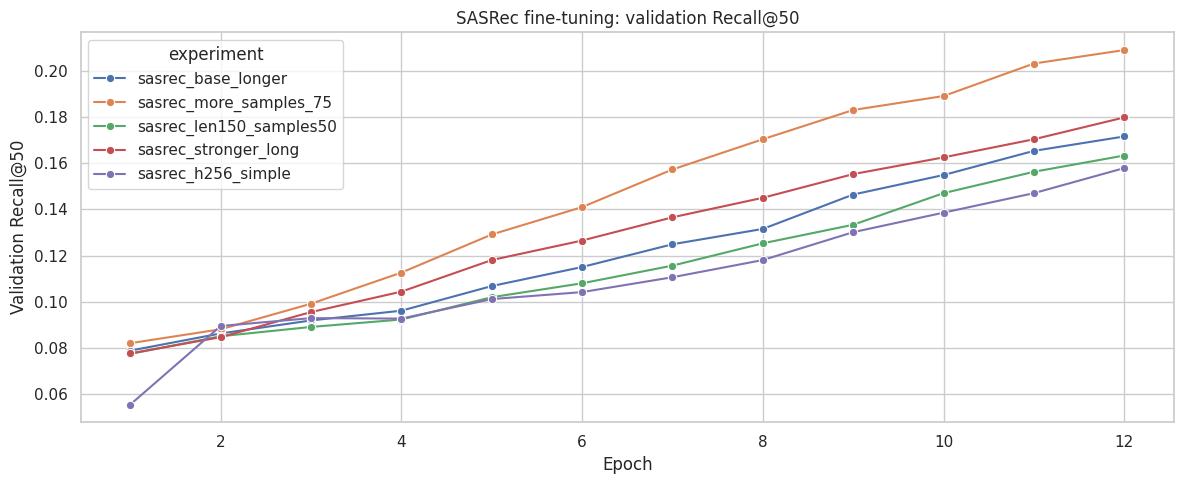

In [ ]:
all_finetune_histories = pd.concat(sasrec_finetune_histories.values(), ignore_index=True)

plt.figure(figsize=(12, 5))
sns.lineplot(data=all_finetune_histories, x="epoch", y="val_Recall@50", hue="experiment", marker="o")

plt.title("SASRec fine-tuning: validation Recall@50")
plt.xlabel("Epoch")
plt.ylabel("Validation Recall@50")
plt.tight_layout()
plt.show()

**Вывод:** На графике видно, что качество почти всех конфигураций продолжает расти до 12-й эпохи, явного переобучения по validation Recall@50 не наблюдается. Лучшая кривая получилась у sasrec_more_samples_75: она стабильно выше остальных почти на всём протяжении обучения. Это подтверждает, что увеличение числа train samples per user оказалось наиболее полезным направлением улучшения.

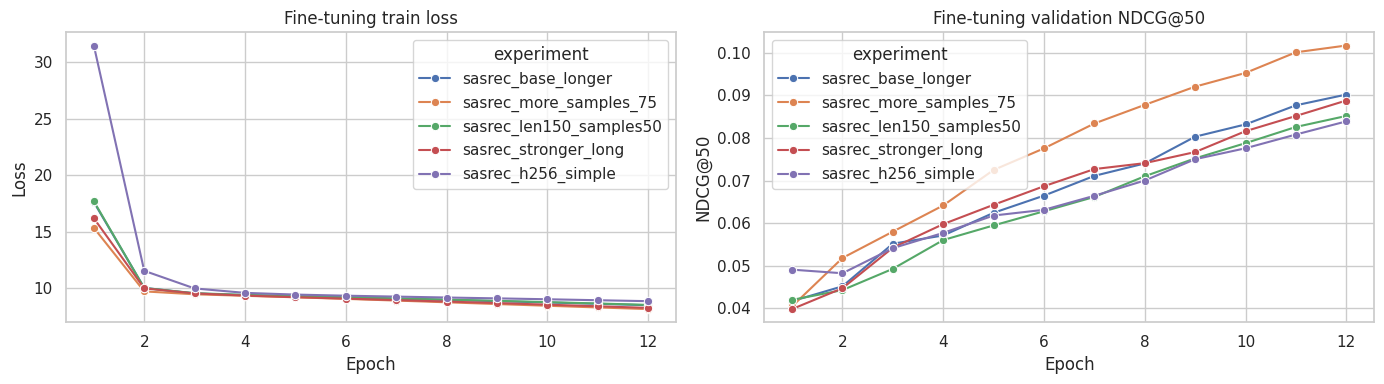

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.lineplot(data=all_finetune_histories, x="epoch", y="train_loss", hue="experiment", marker="o", ax=axes[0])

axes[0].set_title("Fine-tuning train loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

sns.lineplot(data=all_finetune_histories, x="epoch", y="val_NDCG@50", hue="experiment", marker="o", ax=axes[1])

axes[1].set_title("Fine-tuning validation NDCG@50")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("NDCG@50")

plt.tight_layout()
plt.show()

**Вывод:**  Train loss у всех моделей постепенно снижается, а validation NDCG@50 в целом растёт. Это говорит о том, что модели продолжают обучаться содержательным последовательным паттернам, а не просто ухудшают ранжирование на validation. При этом sasrec_more_samples_75 остаётся лучшим и по NDCG@50, поэтому выбранная конфигурация выигрывает не только по факту попадания target в top-50, но и по позиции target внутри рекомендательного списка.

Далее выбирается финальная конфигурация. Выбор делается по validation Recall@50, так как именно эта метрика была основной на этапе fine-tuning. Test-выборка на этом этапе не используется, чтобы избежать подбора модели под test.

## 10. Выбор финальной конфигурации

Финальная конфигурация выбирается по validation Recall@50. Такой выбор фиксирует модель до обращения к тесту и делает итоговую оценку более корректной.

In [ ]:
best_row = sasrec_finetune_results_df.iloc[0]
best_experiment_name = best_row["experiment"]

print("Best fine-tuned SASRec candidate:", best_experiment_name)
display(best_row)

best_config = None

for config in sasrec_finetune_plan:
    if config["name"] == best_experiment_name:
        best_config = config.copy()
        break

best_config

Best fine-tuned SASRec candidate: sasrec_more_samples_75


,1
experiment,sasrec_more_samples_75
model,SASRec
training_type,full_softmax
hidden_dim,128
num_heads,2
num_layers,1
dropout,0.2
lr,0.0005
weight_decay,0.00001
planned_epochs,12


{'name': 'sasrec_more_samples_75',
 'max_len': 100,
 'max_train_samples_per_user': 75,
 'batch_size': 128,
 'hidden_dim': 128,
 'num_heads': 2,
 'num_layers': 1,
 'dropout': 0.2,
 'lr': 0.0005,
 'weight_decay': 1e-05,
 'grad_clip': 1.0,
 'epochs': 12}

**Вывод:** Финальной конфигурацией выбрана sasrec_more_samples_75. Она сохраняет базовую архитектуру SASRec, но использует больше обучающих состояний на пользователя. В этой постановке такой вариант оказался сильнее, чем увеличение числа attention heads, layers, длины контекста или hidden dimension. Поэтому дальше именно эта конфигурация будет обучаться как финальная модель и оцениваться на test.

## 11. Финальное обучениые выбранной SASRec архитектуры

На этом шаге фиксируется конфигурация, выбранная по результатам fine-tuning. В финальном обучении я не меняю архитектуру и параметры подготовки данных, а только увеличиваю число эпох до 30, чтобы проверить, продолжает ли модель улучшаться при более долгом обучении.

In [ ]:
# фиксирую выбранную конфигурацию для финального обучения
final_best_config = best_config.copy()
final_best_config["name"] = "sasrec_final_selected_long"
# увеличиваю число эпох только для финального обучения
final_best_config["epochs"] = 30

final_best_config

{'name': 'sasrec_final_selected_long',
 'max_len': 100,
 'max_train_samples_per_user': 75,
 'batch_size': 128,
 'hidden_dim': 128,
 'num_heads': 2,
 'num_layers': 1,
 'dropout': 0.2,
 'lr': 0.0005,
 'weight_decay': 1e-05,
 'grad_clip': 1.0,
 'epochs': 30}

In [ ]:
(
    final_train_loader,
    final_val_loader,
    final_test_loader,
    final_item2idx,
    final_idx2item,
    final_num_items,
    final_dataset_info
) = rebuild_sequence_dataloaders(
    train_events_eval=train_events_eval,
    val_events=val_events,
    test_events=test_events,
    max_len=final_best_config["max_len"],
    max_train_samples_per_user=final_best_config["max_train_samples_per_user"],
    batch_size=final_best_config["batch_size"]
)

final_train_df, final_val_df, final_test_df = build_sequence_samples(
    train_events_eval=train_events_eval,
    val_events=val_events,
    test_events=test_events,
    item2idx=final_item2idx,
    max_len=final_best_config["max_len"],
    max_train_samples_per_user=final_best_config["max_train_samples_per_user"]
)

final_dataset_info

{'max_len': 100,
 'max_train_samples_per_user': 75,
 'batch_size': 128,
 'num_items': 299842,
 'train_samples': 357085,
 'val_samples': 4973,
 'test_samples': 4973,
 'train_batches': 2790,
 'val_batches': 39,
 'test_batches': 39}

In [ ]:
model_config = {
    "name": final_best_config["name"],
    "hidden_dim": final_best_config["hidden_dim"],
    "num_heads": final_best_config["num_heads"],
    "num_layers": final_best_config["num_layers"],
    "dropout": final_best_config["dropout"],
    "lr": final_best_config["lr"],
    "weight_decay": final_best_config["weight_decay"],
    "grad_clip": final_best_config["grad_clip"],
    "epochs": final_best_config["epochs"],
}

sasrec_final_model, sasrec_final_history, sasrec_final_val_result = run_sasrec_val_only(config=model_config, train_loader=final_train_loader, val_loader=final_val_loader, num_items=final_num_items, max_len=final_best_config["max_len"], device=device,
    max_batches_per_epoch=None,
    patience=6
)

# считаю test-метрики только после фиксации модели
sasrec_final_test_metrics = evaluate_full_softmax(sasrec_final_model, final_test_loader, ks=(10, 50))

sasrec_final_result = {
    **sasrec_final_val_result,
    **sasrec_final_test_metrics,
    "max_len": final_best_config["max_len"],
    "max_train_samples_per_user": final_best_config["max_train_samples_per_user"],
    "batch_size": final_best_config["batch_size"],
    "train_samples": final_dataset_info["train_samples"],
    "val_samples": final_dataset_info["val_samples"],
    "test_samples": final_dataset_info["test_samples"],
    "train_batches": final_dataset_info["train_batches"],
}

pd.DataFrame([sasrec_final_result])

/tmp/ipykernel_2724/502491568.py:37: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(


  0%|          | 0/2790 [00:00<?, ?it/s]

  0%|          | 0/39 [00:00<?, ?it/s]


sasrec_final_selected_long | epoch 1/30
train loss: 15.2566
time sec: 34.95
val: {'Recall@10': 0.043635632415041224, 'Precision@10': 0.004363563241504122, 'NDCG@10': np.float64(0.0324026324264214), 'MRR@10': 0.029018206250259335, 'Recall@50': 0.08304846169314298, 'Precision@50': 0.0016609692338628596, 'NDCG@50': np.float64(0.040854546642374166), 'MRR@50': 0.030705755559333303}


  0%|          | 0/2790 [00:00<?, ?it/s]

...

  0%|          | 0/2790 [00:00<?, ?it/s]

  0%|          | 0/39 [00:00<?, ?it/s]


sasrec_final_selected_long | epoch 30/30
train loss: 6.3600
time sec: 34.95
val: {'Recall@10': 0.1669012668409411, 'Precision@10': 0.016690126684094107, 'NDCG@10': np.float64(0.10514057566286333), 'MRR@10': 0.08593093179359015, 'Recall@50': 0.27086265835511764, 'Precision@50': 0.005417253167102353, 'NDCG@50': np.float64(0.12802116731445914), 'MRR@50': 0.09078996695302247}


  0%|          | 0/39 [00:00<?, ?it/s]

,experiment,model,training_type,hidden_dim,num_heads,num_layers,dropout,lr,weight_decay,planned_epochs,best_epoch,best_val_Recall@50,Recall@10,Precision@10,NDCG@10,MRR@10,Recall@50,Precision@50,NDCG@50,MRR@50,max_len,max_train_samples_per_user,batch_size,train_samples,val_samples,test_samples,train_batches
0,sasrec_final_selected_long,SASRec,full_softmax,128,2,1,0.2,0.0005,0.00001,30,30,0.270863,0.163081,0.016308,0.104186,0.085964,0.271064,0.005421,0.128052,0.091079,100,75,128,357085,4973,4973,2790



## 12. Final learning curves


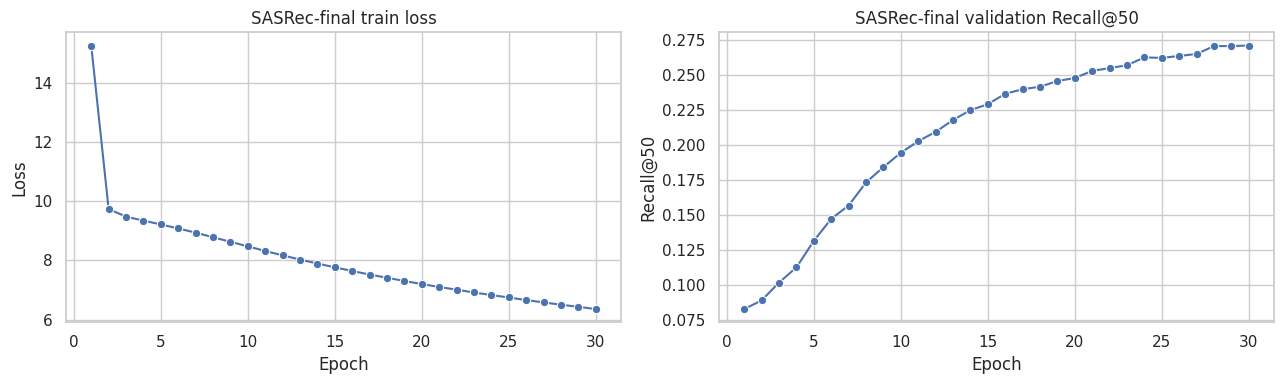

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.lineplot(data=sasrec_final_history, x="epoch", y="train_loss", marker="o", ax=axes[0])
axes[0].set_title("SASRec-final train loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

sns.lineplot(data=sasrec_final_history, x="epoch", y="val_Recall@50", marker="o", ax=axes[1])
axes[1].set_title("SASRec-final validation Recall@50")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Recall@50")

plt.tight_layout()
plt.show()

## 13. Финальная SASRec моедль

В этом блоке для финальной SASRec-модели считаются метрики покрытия, концентрации и popularity bias.


In [ ]:
sasrec_final_recs = generate_sasrec_recommendations( model=sasrec_final_model, loader=final_test_loader, eval_df=final_test_df, idx2item=final_idx2item,top_k=50)
sasrec_final_property_metrics = recommendation_exposure_metrics(recs=sasrec_final_recs, model_name="SASRec-final", item_universe=item_universe, popularity_bin_map=popularity_bin_map, ks=(10, 50))

sasrec_final_property_metrics

  0%|          | 0/39 [00:00<?, ?it/s]

,model,K,Unique Recommended Items@K,Catalog Coverage@K,Gini@K
0,SASRec-final,10,15591,0.051998,0.603823
1,SASRec-final,50,34711,0.115765,0.752717


In [ ]:
sasrec_final_accuracy_long = pd.DataFrame([
    {
        "model": "SASRec-final",
        "K": k,
        "Recall@K": sasrec_final_result[f"Recall@{k}"],
        "Precision@K": sasrec_final_result[f"Precision@{k}"],
        "NDCG@K": sasrec_final_result[f"NDCG@{k}"],
        "MRR@K": sasrec_final_result[f"MRR@{k}"],
    }
    for k in (10, 50)
])

In [ ]:
sasrec_final_metrics_long = sasrec_final_accuracy_long.merge(sasrec_final_property_metrics,on=["model", "K"],how="left")

sasrec_final_metrics_at50 = (sasrec_final_metrics_long.query("K == 50").copy().rename(columns={
        "Recall@K": "Recall@50",
        "Precision@K": "Precision@50",
        "NDCG@K": "NDCG@50",
        "MRR@K": "MRR@50",
        "Catalog Coverage@K": "Catalog Coverage@50",
        "Unique Recommended Items@K": "Unique Recommended Items@50",
        "Gini@K": "Gini@50"}))

sasrec_final_metrics_at50

,model,K,Recall@50,Precision@50,NDCG@50,MRR@50,Unique Recommended Items@50,Catalog Coverage@50,Gini@50
1,SASRec-final,50,0.271064,0.005421,0.128052,0.091079,34711,0.115765,0.752717


**Вывод:** финальная SASRec-модель показала лучший результат по основной метрике качества: Recall@50 составил 0.271. Это означает, что примерно для 27% пользователей фактический следующий трек попал в топ-50 рекомендаций. По сравнению с предыдущими SASRec-кандидатами качество заметно выросло, поэтому выбранная конфигурация может использоваться как финальная модель для дальнейшего сравнения.

При этом модель всё ещё сильно ориентируется на популярные треки: Catalog Coverage@50 равен 0.116, а Gini@50 - 0.753, то есть покрытие каталога стало шире, чем у простых baseline-моделей, но рекомендации остаются достаточно сконцентрированными.